# RNN vs LSTM vs GRU on AG News (PyTorch)
Includes model selection and confusion matrix

In [ ]:
#%pip install datasets

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [2]:

dataset = load_dataset("ag_news")
train_data = list(dataset["train"])[:5000]
test_data = list(dataset["test"])[:1000]

In [3]:

def tokenize(text):
    return text.lower().split()

counter = Counter()
for item in train_data:
    counter.update(tokenize(item["text"]))

vocab = {w:i+2 for i,(w,_) in enumerate(counter.most_common(10000))}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

In [4]:

max_len = 25

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(t,1) for t in tokens]
    if len(ids) < max_len:
        ids += [0]*(max_len-len(ids))
    else:
        ids = ids[:max_len]
    return torch.tensor(ids)

def collate(batch):
    X, y = [], []
    for item in batch:
        X.append(encode(item["text"]))
        y.append(item["label"])
    return torch.stack(X), torch.tensor(y)


In [5]:

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate)


In [6]:

class Model(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 4)

    def forward(self, x):
        x = self.embedding(x)
        x = self.dropout(x)
        out, h = self.rnn(x)
        if isinstance(h, tuple):
            h = h[0]
        return self.fc(h[-1])


In [7]:

def train_model(model_type):
    model = Model(model_type, len(vocab), 128, 128, 3).to(device)

    optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    for epoch in range(50):
        model.train()
        tl, correct, total = 0,0,0

        for X,y in train_loader:
            X,y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)

            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = criterion(out,y) + 1e-6*l1

            loss.backward()
            optimizer.step()

            tl += loss.item()
            preds = out.argmax(1)
            correct += (preds==y).sum().item()
            total += y.size(0)

        train_loss = tl/len(train_loader)
        train_acc = correct/total

        model.eval()
        vl, correct, total = 0,0,0

        with torch.no_grad():
            for X,y in val_loader:
                X,y = X.to(device), y.to(device)
                out = model(X)
                loss = criterion(out,y)

                vl += loss.item()
                preds = out.argmax(1)
                correct += (preds==y).sum().item()
                total += y.size(0)

        val_loss = vl/len(val_loader)
        val_acc = correct/total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return model, history


In [8]:

models = {}
histories = {}
best_model_name = None
best_val_acc = 0

for m in ["RNN","LSTM","GRU"]:
    model, hist = train_model(m)
    models[m] = model
    histories[m] = hist

    if max(hist["val_acc"]) > best_val_acc:
        best_val_acc = max(hist["val_acc"])
        best_model_name = m

print("Best model:", best_model_name)


Best model: GRU


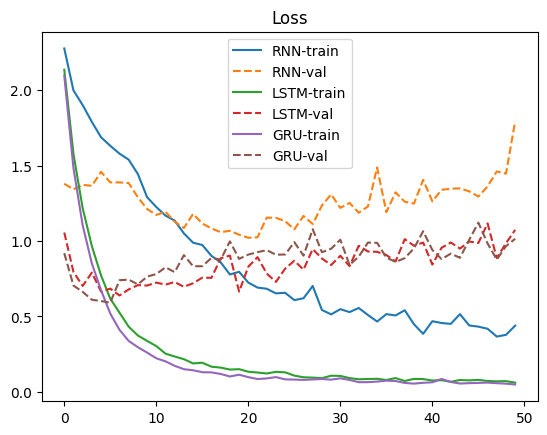

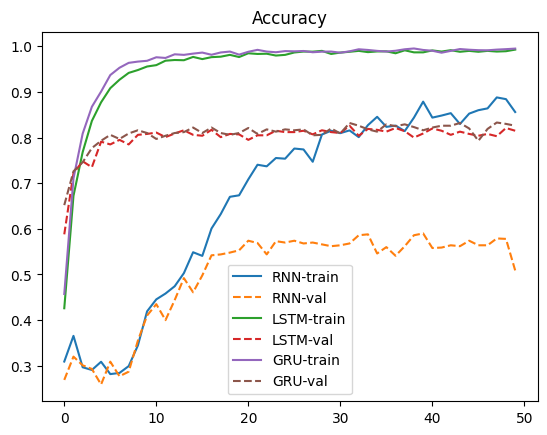

In [9]:

for m in histories:
    plt.plot(histories[m]["train_loss"], label=f"{m}-train")
    plt.plot(histories[m]["val_loss"], linestyle='--', label=f"{m}-val")
plt.legend(); plt.title("Loss"); plt.show()

for m in histories:
    plt.plot(histories[m]["train_acc"], label=f"{m}-train")
    plt.plot(histories[m]["val_acc"], linestyle='--', label=f"{m}-val")
plt.legend(); plt.title("Accuracy"); plt.show()


In [10]:

full_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate)

best_model = Model(best_model_name, len(vocab), 128, 128, 2).to(device)
optimizer = optim.Adam(best_model.parameters(), lr=2e-3)

for epoch in range(50):
    best_model.train()
    for X,y in full_loader:
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = nn.CrossEntropyLoss()(best_model(X), y)
        loss.backward()
        optimizer.step()


Test Accuracy: 0.775


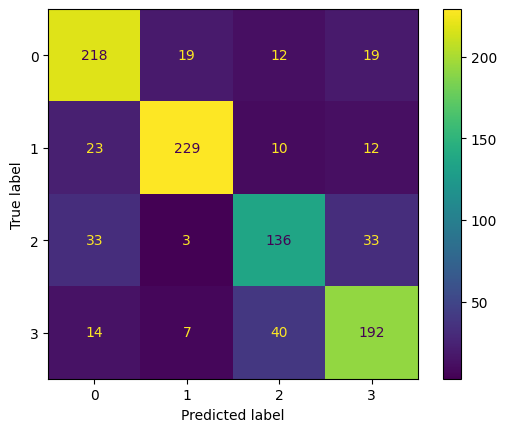

In [11]:

best_model.eval()
preds_all, labels_all = [], []

with torch.no_grad():
    for X,y in test_loader:
        X,y = X.to(device), y.to(device)
        preds = best_model(X).argmax(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())

acc = np.mean(np.array(preds_all)==np.array(labels_all))
print("Test Accuracy:", acc)

cm = confusion_matrix(labels_all, preds_all)
ConfusionMatrixDisplay(cm).plot()
plt.show()
